# A3 – Network Data Preparation and Generation
This notebook prepares and cleans the road and bridge data from `_roads3.csv` and `BMMS_overview.xlsx` to produce a simulation-ready CSV file for the Mesa/NetworkX network model of N1, N2, and their side roads (>25 km).

In [1]:
import pandas as pd
import numpy as np
import math
import re
import matplotlib.pyplot as plt

# Load the two source files
road_data = pd.read_csv('../data/_roads3.csv')
bridge_data = pd.read_excel('../data/BMMS_overview.xlsx')

print(f"_roads3.csv:        {road_data.shape[0]} rows, {road_data.shape[1]} columns")
print(f"BMMS_overview.xlsx: {bridge_data.shape[0]} rows, {bridge_data.shape[1]} columns")
print(f"\n _roads3.csv columns\n{list(road_data.columns)}")
print(f"\n BMMS_overview.xlsx columns\n{list(bridge_data.columns)}")
print(f"\n _roads3.csv 'type' values\n{road_data['type'].value_counts().head(15)}")
print(f"\n _roads3.csv sample rows")
road_data.head(10)

_roads3.csv:        51348 rows, 8 columns
BMMS_overview.xlsx: 20415 rows, 20 columns

 _roads3.csv columns
['road', 'chainage', 'lrp', 'lat', 'lon', 'gap', 'type', 'name']

 BMMS_overview.xlsx columns
['road', 'km', 'type', 'LRPName', 'name', 'length', 'condition', 'structureNr', 'roadName', 'chainage', 'width', 'constructionYear', 'spans', 'zone', 'circle', 'division', 'sub-division', 'lat', 'lon', 'EstimatedLoc']

 _roads3.csv 'type' values
type
KmPost               19467
Culvert              17542
Bridge                8933
Others                2472
SideRoad,Right         628
SideRoad,Left          613
RailRoadCrossing       320
CrossRoad              296
Turnoff,Right          202
Turnoff,Left           168
Others / Others        123
Bridge / Bridge        103
Culvert / Culvert       67
Monument                64
KmPost / KmPost         63
Name: count, dtype: int64

 _roads3.csv sample rows


,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,0.814,LRPSa,23.702917,90.450417,NaN,Culvert,Box Culvert
2,N1,0.822,LRPSb,23.702778,90.450472,NaN,CrossRoad,Intersection with Z1101
3,N1,1.000,LRP001,23.702139,90.451972,NaN,KmPost,Km post missing
4,N1,2.000,LRP002,23.697889,90.460583,NaN,KmPost,Km post missing
5,N1,2.130,LRP002a,23.697361,90.461667,NaN,Culvert,Box culvert
6,N1,3.000,LRP003,23.693833,90.469138,NaN,KmPost,Km post missing
7,N1,4.000,LRP004,23.693611,90.478777,NaN,KmPost,Km post missing
8,N1,4.175,LRP004a,23.693805,90.480527,NaN,"SideRoad,Right",Road to Narayanganj(R111)
9,N1,5.000,LRP005,23.694750,90.488500,NaN,KmPost,Km post missing


In [2]:
import math
import re

# Regex that matches N-road names including those with a space (e.g. "N 2", "N 208")
N_ROAD_PATTERN = re.compile(r'\bN\s?\d{1,3}\b')


def extract_nroads(text):
    """Extract N-road names from text, normalizing 'N 2' -> 'N2', 'N 208' -> 'N208'."""
    return {m.replace(' ', '') for m in N_ROAD_PATTERN.findall(str(text))}


# ── Helpers ───────────────────────────────────────────────────────

def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance between two lat/lon points in **meters** (Haversine)."""
    R = 6_371_000  # Earth's radius in metres
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def is_within_distance(lat1, lon1, lat2, lon2, x):
    """Return True if two geographic points are within *x* meters of each other."""
    return haversine_distance(lat1, lon1, lat2, lon2) <= x


def find_nearest_bridge_on_road(lat, lon, bridge_df, road_name):
    """Return (nearest_row, distance_m) for the closest BMMS bridge on *road_name*."""
    road_bridges = bridge_df[bridge_df['road'] == road_name]
    min_dist = float('inf')
    nearest = None
    for _, row in road_bridges.iterrows():
        d = haversine_distance(lat, lon, row['lat'], row['lon'])
        if d < min_dist:
            min_dist = d
            nearest = row
    return nearest, min_dist


def get_all_bridges_at_crossing(bridge_record, bridge_df):
    """Return list of all bridge records at the same crossing (same road & chainage)."""
    same_crossing = bridge_df[
        (bridge_df['road'] == bridge_record['road']) &
        (bridge_df['chainage'] == bridge_record['chainage'])
    ]
    return [row.to_dict() for _, row in same_crossing.iterrows()]


# ── Side-road identification ─────────────────────────────────────

def identify_intersecting_sideroads(road_df):
    """
    Identify all N-type side roads that intersect with N1 and N2.
    Returns a sorted list of unique road names (e.g. ['N101', 'N105', ...]).
    """
    main_roads = {'N1', 'N2'}
    sideroads = set()

    for _, row in road_df.iterrows():
        row_type = str(row['type']).strip() if pd.notna(row['type']) else ''
        if not any(t in row_type for t in ['SideRoad', 'CrossRoad', 'Others']):
            continue

        roads_in_road = extract_nroads(row['road'])
        roads_in_name = extract_nroads(row['name'])

        if roads_in_road & main_roads:
            sideroads.update(roads_in_name - main_roads)
        if roads_in_name & main_roads:
            sideroads.update(roads_in_road - main_roads)

    return sorted(sideroads, key=lambda x: (len(x), x))


def filter_roads_by_minimum_length(road_list, road_df, min_km=25):
    """Keep only roads whose maximum chainage exceeds *min_km* kilometres."""
    filtered = []
    for road in road_list:
        road_rows = road_df[road_df['road'] == road]
        if road_rows.empty:
            continue
        max_chainage = road_rows['chainage'].max()
        if max_chainage > min_km:
            filtered.append(road)
        else:
            print(f"  Removed {road}: max chainage {max_chainage:.1f} km <= {min_km} km")
    return filtered


def add_missing_sideroads(road_list):
    """Manually add side roads not found by identify_intersecting_sideroads."""
    missing = ['N106']
    for road in missing:
        if road not in road_list:
            road_list.append(road)
            print(f"  Manually added missing side road: {road}")
    return road_list


# ── Intersection post-processing ─────────────────────────────────

def unify_intersection_identifiers(df_road_file, merge_threshold_m=500):
    """
    Pair matching intersection rows and assign them the same ID.

    Two rows are paired when one's 'road' appears in the other's 'name'
    and they are within *merge_threshold_m* metres of each other.

    Threshold rationale: the two paired rows (e.g. N1's record of 'crosses N2'
    and N2's record of 'crosses N1') represent the same physical point. The
    500 m threshold accommodates typical GPS and chainage rounding errors in
    _roads3.csv (~100-300 m) while being tight enough to never accidentally
    merge two distinct intersections, which are always several kilometres apart
    on Bangladesh's national road network.
    """
    intersections = df_road_file[df_road_file['model_type'] == 'intersection'].copy()
    if intersections.empty:
        return df_road_file

    int_info = []
    for idx, row in intersections.iterrows():
        road = str(row['road']).strip()
        refs = extract_nroads(row['name'])
        int_info.append((idx, road, refs, row['lat'], row['lon'], row['id']))

    pairs = []
    for i in range(len(int_info)):
        for j in range(i + 1, len(int_info)):
            idx_a, road_a, refs_a, lat_a, lon_a, id_a = int_info[i]
            idx_b, road_b, refs_b, lat_b, lon_b, id_b = int_info[j]
            if road_b in refs_a or road_a in refs_b:
                dist = haversine_distance(lat_a, lon_a, lat_b, lon_b)
                if dist <= merge_threshold_m:
                    shared_id = min(id_a, id_b)
                    df_road_file.at[idx_a, 'id'] = shared_id
                    df_road_file.at[idx_b, 'id'] = shared_id
                    pairs.append((road_a, road_b, shared_id, dist))

    print(f"  Unified {len(pairs)} intersection pairs (threshold: {merge_threshold_m} m)")
    for road_a, road_b, sid, dist in pairs:
        print(f"    {road_a} <-> {road_b}: id={sid}, distance={dist:.0f} m")

    # Validate: no ID should appear in more than 2 intersection rows.
    id_counts = df_road_file[df_road_file['model_type'] == 'intersection']['id'].value_counts()
    over_paired = id_counts[id_counts > 2]
    if not over_paired.empty:
        print(f"WARNING: {len(over_paired)} intersection ID(s) appear in >2 rows:")
        for bad_id, count in over_paired.items():
            bad_rows = df_road_file[
                (df_road_file['model_type'] == 'intersection') &
                (df_road_file['id'] == bad_id)
            ]
            print(f"    id={bad_id} appears {count} times: roads={bad_rows['road'].tolist()}")
    return df_road_file


def insert_row_after_lrp(df, target_lrp, row_dict):
    """
    Insert row_dict into df immediately after the row whose 'lrp' == target_lrp
    on the same road. Raises ValueError if target_lrp is not found.
    """
    road = row_dict['road']
    mask = (df['road'] == road) & (df['lrp'] == target_lrp)
    matches = df.index[mask].tolist()
    if not matches:
        raise ValueError(f"LRP '{target_lrp}' not found on road '{road}'")
    insert_pos = matches[-1] + 1          # position after the last match
    upper = df.iloc[:insert_pos]
    lower = df.iloc[insert_pos:]
    return pd.concat([upper, pd.DataFrame([row_dict]), lower], ignore_index=True)


def handle_intersection_edge_cases(df_road_file, road_list):
    """
    Manually inject intersection rows for edge cases not caught by the main loop:
      1. sourcesink rows that also serve as intersections (detected via name column)
      2. N1-N106: an intersection node is inserted on N1 at the actual LRPS of N106
         ("Oxygen More", 22.3935552, 91.8215827). The existing N106 LRPS sourcesink
         row is updated in-place to share the same ID (no new N106 row added).
      3. N104-N1: N1 already has the correctly detected row (CrossRoad LRP148a, id=1000377).
         We mirror it on N104 at the exact same coordinates so unify_intersection_identifiers
         pairs them and both share id=1000377.
      4. N105 missing LRPE sourcesink: last row is KmPost/Others, not a proper LRPE.
    """
    rows_to_insert = []
    next_id = int(df_road_file['id'].max()) + 1

    # Category 1: sourcesink rows that are also intersections
    sourcesinks = df_road_file[df_road_file['model_type'] == 'sourcesink']
    for idx, row in sourcesinks.iterrows():
        name = str(row['name']) if pd.notna(row['name']) else ''
        road = str(row['road']).strip()
        refs = extract_nroads(name) - {road}
        matching = refs & set(road_list)
        if matching:
            for ref_road in matching:
                rows_to_insert.append({
                    'road': road, 'id': next_id, 'model_type': 'intersection',
                    'name': f'Intersection {road}-{ref_road}',
                    'lat': row['lat'], 'lon': row['lon'],
                    'length': np.nan, 'condition': '', 'lrp': row.get('lrp', '')
                })
                print(f"  Edge case: {road} sourcesink is also intersection with {ref_road} (id={next_id})")
                next_id += 1

    # Category 2: N1-N106 intersection — placed at the actual LRPS of N106 ("Oxygen More").
    # LRP235b (22.3587, 91.7823) marks where the N1 survey data ends entering Chittagong
    # city; LRP244b (22.3644, 91.8511) marks where it resumes. N106 starts (LRPS) at
    # (22.3935552, 91.8215827), which is the actual junction with N1 in this gap.
    # The N1 intersection node (lrp=LRP235c) is inserted after LRP235b; the N106 LRPS
    # sourcesink row is updated in-place to carry the shared ID.
    if 'N106' in road_list and 'N1' in road_list:
        existing = df_road_file[
            (df_road_file['model_type'] == 'intersection') &
            (df_road_file['road'] == 'N1') &
            (df_road_file['name'].str.contains('N106', na=False))
        ]
        if existing.empty:
            # N106 LRPS coordinates ("Oxygen More", chainage 0.0 km)
            int_lat = 22.3935552
            int_lon = 91.8215827
            shared_id = next_id
            next_id += 1
            # N1 intersection node — inserted after LRP235b (see insert_row_after_lrp below)
            rows_to_insert.append({
                'road': 'N1', 'id': shared_id, 'model_type': 'intersection',
                'name': 'Intersection N1-N106 (at N106 LRPS, Oxygen More)',
                'lat': int_lat, 'lon': int_lon,
                'length': np.nan, 'condition': '', 'lrp': 'LRP235c'
            })
            # Update existing N106 LRPS sourcesink row in-place (no new row added)
            n106_lrps_mask = (
                (df_road_file['road'] == 'N106') &
                (df_road_file['lrp'] == 'LRPS') &
                (df_road_file['model_type'] == 'sourcesink')
            )
            n106_lrps_idx = df_road_file.index[n106_lrps_mask]
            if not n106_lrps_idx.empty:
                df_road_file.loc[n106_lrps_idx, 'id'] = shared_id
                df_road_file.loc[n106_lrps_idx, 'name'] = (
                    'Start of Road from Oxygen More (also N1-N106 intersection)'
                )
            print(f"  Edge case: N1-N106 intersection at N106 LRPS "
                  f"({int_lat:.7f}, {int_lon:.7f}), shared id={shared_id}")
            print(f"    N106 LRPS sourcesink updated to id={shared_id} "
                  f"(also serves as N1-N106 intersection)")

    # Category 3: N104-N1 intersection (N104 LRPS references 'Z1031' instead of 'N1').
    # N1 already has the correctly detected row (CrossRoad entry, LRP148a, id=1000377).
    # We add a mirror row on N104 at the exact same coordinates so that
    # unify_intersection_identifiers pairs them and both share id=1000377.
    if 'N104' in road_list and 'N1' in road_list:
        existing_n104 = df_road_file[
            (df_road_file['model_type'] == 'intersection') &
            (df_road_file['road'] == 'N104') &
            (df_road_file['name'].str.contains('N1', na=False))
        ]
        if existing_n104.empty:
            n1_n104_row = df_road_file[
                (df_road_file['model_type'] == 'intersection') &
                (df_road_file['road'] == 'N1') &
                (df_road_file['name'].str.contains('N104', na=False))
            ]
            if not n1_n104_row.empty:
                int_lat = n1_n104_row.iloc[0]['lat']
                int_lon = n1_n104_row.iloc[0]['lon']
            else:
                int_lat, int_lon = 23.009556, 91.381360  # LRP148a fallback
            rows_to_insert.append({
                'road': 'N104', 'id': next_id, 'model_type': 'intersection',
                'name': 'Intersection N104-N1',
                'lat': int_lat, 'lon': int_lon,
                'length': np.nan, 'condition': '', 'lrp': 'LRP001a'
            })
            print(f"  Edge case: Added N104-N1 intersection on N104 at ({int_lat:.6f}, {int_lon:.6f}) (id={next_id})")
            next_id += 1

    # Category 4: N105 missing LRPE sourcesink
    # The last row of N105 in _roads3.csv is LRP048 (type 'KmPost / Others'), not a proper
    # LRPE row, so build_simulation_network never creates a closing sourcesink.
    # Coordinates taken from that last row (chainage 48.87 km, "End of Road at N4, Joydebpur").
    if 'N105' in road_list:
        existing_lrpe = df_road_file[
            (df_road_file['road'] == 'N105') &
            (df_road_file['model_type'] == 'sourcesink') &
            (df_road_file['lrp'] == 'LRPE')
        ]
        if existing_lrpe.empty:
            rows_to_insert.append({
                'road': 'N105', 'id': next_id, 'model_type': 'sourcesink',
                'name': 'End of Road Intersection at N4 at Joydebpur (LRP048)',
                'lat': 23.9895274, 'lon': 90.3582222,
                'length': np.nan, 'condition': '', 'lrp': 'LRPE'
            })
            print(f"  Edge case: Added missing N105 LRPE sourcesink at LRP048 (id={next_id})")
            next_id += 1

    # Insert rows at their correct road position (sorted by chainage), never appended to end.
    # Anchor overrides for rows whose lrp alone is ambiguous.
    _ANCHOR_OVERRIDES = {
        ('N105', 'LRPE'): 'LRP048',      # N105 LRPE goes after last real N105 row
        ('N104', 'LRP001a'): 'LRP001a',  # N104-N1 intersection after LRP001a
    }

    for row_dict in rows_to_insert:
        road = row_dict['road']
        lrp  = row_dict.get('lrp', '')
        if lrp == 'LRP235c':
            anchor = 'LRP235b'
        else:
            anchor = _ANCHOR_OVERRIDES.get((road, lrp), lrp)
        df_road_file = insert_row_after_lrp(df_road_file, anchor, row_dict)
        print(f"    Inserted {road} (lrp={lrp}) after anchor '{anchor}' in sequence")

    print(f"  Total edge-case rows added: {len(rows_to_insert)}")
    return df_road_file


def align_n1_n2_intersection_ids(df_road_file):
    """Ensure the N1-N2 intersection pair shares the same (lower) ID."""
    n1_int = df_road_file[
        (df_road_file['model_type'] == 'intersection') &
        (df_road_file['road'] == 'N1') &
        (df_road_file['name'].str.contains(r'\bN2\b', regex=True, na=False))
    ]
    n2_int = df_road_file[
        (df_road_file['model_type'] == 'intersection') &
        (df_road_file['road'] == 'N2') &
        (df_road_file['name'].str.contains(r'\bN1\b', regex=True, na=False))
    ]
    if not n1_int.empty and not n2_int.empty:
        shared_id = min(n1_int.iloc[0]['id'], n2_int.iloc[0]['id'])
        df_road_file.loc[n1_int.index, 'id'] = shared_id
        df_road_file.loc[n2_int.index, 'id'] = shared_id
        print(f"  Aligned N1-N2 intersection IDs to {shared_id}")
    else:
        print("  Warning: could not find both N1-N2 intersection entries")
    return df_road_file


# ── Distance computation ─────────────────────────────────────────

def compute_inter_node_distances(df_road_file):
    """
    Fill NaN lengths by computing the Haversine distance to the preceding row.
    Processes each road separately; the first entry of each road gets length 0.
    """
    df = df_road_file.copy()
    for road in df['road'].unique():
        road_indices = df.index[df['road'] == road]
        for pos, idx in enumerate(road_indices):
            if pd.isna(df.at[idx, 'length']):
                if pos == 0:
                    df.at[idx, 'length'] = 0
                else:
                    prev_idx = road_indices[pos - 1]
                    d = haversine_distance(
                        df.at[prev_idx, 'lat'], df.at[prev_idx, 'lon'],
                        df.at[idx, 'lat'], df.at[idx, 'lon']
                    )
                    df.at[idx, 'length'] = round(d)
    df['length'] = df['length'].round().astype(int)
    return df


# ── Build Simulation Network ──────────────────

def build_simulation_network(road_df, bridge_df, main_roads=None):
    """
    Build a simulation-ready dataframe from _roads3.csv and BMMS_overview.xlsx.

    Steps:
      1. Identify intersecting N-type side roads for N1 and N2.
      2. Filter side roads to those > 25 km.
      3. Add manually missing side roads.
      4. Process every road: classify each row as sourcesink, link, bridge,
         or intersection and collect structured entries.

    Returns (df_road_file, road_list).
    """
    if main_roads is None:
        main_roads = ['N1', 'N2']

    print("Step 1: Identifying intersecting side roads ...")
    sideroads = identify_intersecting_sideroads(road_df)
    print(f"  Found {len(sideroads)} candidate side roads: {sideroads}")

    print("\nStep 2: Filtering roads by 25 km minimum length ...")
    sideroads = filter_roads_by_minimum_length(sideroads, road_df, min_km=25)
    print(f"  {len(sideroads)} side roads after filtering: {sideroads}")

    print("\nStep 3: Adding manually missing side roads ...")
    sideroads = add_missing_sideroads(sideroads)

    road_list = main_roads + sideroads
    print(f"\nFull road list ({len(road_list)} roads): {road_list}")

    print("\nStep 4: Processing roads ...")
    entries = []
    id_counter = {}
    for idx, road in enumerate(road_list):
        id_counter[road] = (idx + 1) * 1_000_000

    for road_name in road_list:
        rd = road_df[road_df['road'] == road_name].reset_index(drop=True)
        if rd.empty:
            print(f"  Warning: no data for road '{road_name}', skipping.")
            continue

        cid = id_counter[road_name]
        link_n = bridge_n = intersection_n = 0

        def next_id():
            nonlocal cid
            current = cid
            cid += 1
            return current

        def add_entry(model_type, name, lat, lon, length, condition='', lrp=''):
            entries.append(dict(
                road=road_name, id=next_id(), model_type=model_type,
                name=name, lat=lat, lon=lon,
                length=length, condition=condition, lrp=lrp,
            ))

        i = 0
        while i < len(rd):
            s = rd.iloc[i]
            stype = str(s['type']).strip() if pd.notna(s['type']) else ''
            sgap = str(s['gap']).strip() if pd.notna(s['gap']) else ''
            slrp = str(s['lrp']).strip() if pd.notna(s['lrp']) else ''
            sname = str(s['name']).strip() if pd.notna(s['name']) else ''

            # ═══ Road Start (LRPS) → sourcesink ═══
            if slrp == 'LRPS' and 'Others' in stype:
                add_entry('sourcesink', sname, s['lat'], s['lon'], 0.0, lrp=slrp)
                i += 1

            # ═══ Road End (LRPE) → sourcesink ═══
            elif slrp == 'LRPE' and 'Others' in stype:
                add_entry('sourcesink', sname, s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

            # ═══ Culvert ═══
            elif 'Culvert' in stype:
                link_n += 1
                add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                nearest, dist = find_nearest_bridge_on_road(
                    s['lat'], s['lon'], bridge_df, road_name)
                if nearest is not None and dist <= 50:
                    all_bridges = get_all_bridges_at_crossing(nearest, bridge_df)
                    bridge_n += 1
                    blen = nearest['length'] if pd.notna(nearest['length']) else 0
                    bcond = nearest['condition'] if pd.notna(nearest['condition']) else 'B'
                    bname = nearest['name'] if pd.notna(nearest['name']) and nearest['name'] != '.' else f'bridge {bridge_n}'
                    if len(all_bridges) > 1:
                        bname = f'{bname} ({len(all_bridges)} bridges at crossing)'
                    add_entry('bridge', bname, s['lat'], s['lon'], blen, bcond, lrp=slrp)
                i += 1

            # ═══ Bridge (BS/BE) ═══
            elif 'Bridge' in stype:
                if sgap == 'BS':
                    bs_lat, bs_lon = s['lat'], s['lon']
                    link_n += 1
                    add_entry('link', f'link {link_n}', bs_lat, bs_lon, np.nan, lrp=slrp)

                    be_lat = be_lon = be_lrp = None
                    if (i + 1 < len(rd)
                            and str(rd.iloc[i + 1]['gap']).strip() == 'BE'):
                        nxt = rd.iloc[i + 1]
                        be_lat, be_lon = nxt['lat'], nxt['lon']
                        be_lrp = str(nxt['lrp']).strip()

                    if be_lat is not None:
                        blat = (bs_lat + be_lat) / 2
                        blon = (bs_lon + be_lon) / 2
                    else:
                        blat, blon = bs_lat, bs_lon

                    nearest, dist = find_nearest_bridge_on_road(
                        blat, blon, bridge_df, road_name)
                    bridge_n += 1

                    if nearest is not None and dist <= 200:
                        all_bridges = get_all_bridges_at_crossing(nearest, bridge_df)
                        blen = nearest['length'] if pd.notna(nearest['length']) else 0
                        bcond = nearest['condition'] if pd.notna(nearest['condition']) else 'B'
                        bname = nearest['name'] if pd.notna(nearest['name']) and nearest['name'] != '.' else sname
                        if len(all_bridges) > 1:
                            bname = f'{bname} ({len(all_bridges)} bridges at crossing)'
                    else:
                        blen, bcond = 0, 'B'
                        bname = sname if sname else f'bridge {bridge_n} (dummy)'

                    add_entry('bridge', bname, blat, blon, blen, bcond, lrp=slrp)

                    if be_lat is not None:
                        link_n += 1
                        add_entry('link', f'link {link_n}', be_lat, be_lon, 0, lrp=be_lrp)
                        i += 2
                    else:
                        i += 1
                else:
                    link_n += 1
                    add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                    i += 1

            # ═══ Intersection detection (CrossRoad / SideRoad) ═══
            elif any(t in stype for t in ['CrossRoad', 'SideRoad']):
                road_refs = extract_nroads(sname)
                road_col_refs = extract_nroads(s['road'])
                matching_roads = ((road_refs | road_col_refs) - {road_name}) & set(road_list)
                if matching_roads:
                    intersection_n += 1
                    add_entry('intersection', sname, s['lat'], s['lon'], np.nan, lrp=slrp)
                else:
                    link_n += 1
                    add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

            # ═══ Default → link ═══
            else:
                link_n += 1
                add_entry('link', f'link {link_n}', s['lat'], s['lon'], np.nan, lrp=slrp)
                i += 1

        print(f"  {road_name}: {link_n} links, {bridge_n} bridges, "
              f"{intersection_n} intersections, {cid - id_counter[road_name]} total entries")

    df_road_file = pd.DataFrame(entries)
    return df_road_file, road_list


# ── Execute ──────────────────────────────────────────────────────

print('Building simulation network ...')
df_road_file, road_list = build_simulation_network(road_data, bridge_data)

print('\nHandling intersection edge cases ...')
df_road_file = handle_intersection_edge_cases(df_road_file, road_list)

print('\nUnifying intersection identifiers ...')
df_road_file = unify_intersection_identifiers(df_road_file)

print('\nAligning N1-N2 intersection IDs ...')
df_road_file = align_n1_n2_intersection_ids(df_road_file)

print('\nComputing inter-node distances ...')
df_road_file = compute_inter_node_distances(df_road_file)

# Save
save_path = '../data/network_data.csv'
df_road_file.to_csv(save_path, index=False)
print(f'\nSaved  {save_path}  ({df_road_file.shape[0]} rows x {df_road_file.shape[1]} cols)')
print(f'\nmodel_type breakdown:\n{df_road_file["model_type"].value_counts().to_string()}')
print(f'\nRoads included: {df_road_file["road"].unique().tolist()}')

# ── Zero-length diagnostic ────────────────────────────────────────────
_zero = df_road_file[
    (df_road_file['length'] == 0) &
    (df_road_file['model_type'].isin(['link', 'bridge']))
].copy()
_zero_links   = _zero[_zero['model_type'] == 'link']
_zero_bridges = _zero[_zero['model_type'] == 'bridge']
print(f'\nZero-length components: {len(_zero)} total '
      f'({len(_zero_links)} links, {len(_zero_bridges)} bridges)')
if not _zero_bridges.empty:
    print('\nZero-length bridges:')
    print(_zero_bridges[['road', 'id', 'model_type', 'name', 'lrp']].to_string(index=False))
df_road_file

Building simulation network ...
Step 1: Identifying intersecting side roads ...
  Found 22 candidate side roads: ['N102', 'N104', 'N105', 'N107', 'N108', 'N109', 'N110', 'N111', 'N112', 'N119', 'N120', 'N123', 'N128', 'N129', 'N203', 'N204', 'N205', 'N206', 'N207', 'N208', 'N209', 'N210']

Step 2: Filtering roads by 25 km minimum length ...
  Removed N107: max chainage 10.5 km <= 25 km
  Removed N108: max chainage 22.5 km <= 25 km
  Removed N109: max chainage 2.5 km <= 25 km
  Removed N110: max chainage 7.6 km <= 25 km
  Removed N111: max chainage 12.7 km <= 25 km
  Removed N112: max chainage 2.7 km <= 25 km
  Removed N119: max chainage 2.4 km <= 25 km
  Removed N120: max chainage 20.9 km <= 25 km
  Removed N123: max chainage 8.1 km <= 25 km
  Removed N128: max chainage 1.3 km <= 25 km
  Removed N129: max chainage 2.8 km <= 25 km
  Removed N203: max chainage 1.0 km <= 25 km
  Removed N205: max chainage 2.5 km <= 25 km
  Removed N206: max chainage 1.8 km <= 25 km
  Removed N209: max cha

,road,id,model_type,name,lat,lon,length,condition,lrp
0,N1,1000000,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,,LRPS
1,N1,1000001,link,link 1,23.702917,90.450417,800,,LRPSa
2,N1,1000002,link,link 2,23.702778,90.450472,16,,LRPSb
3,N1,1000003,link,link 3,23.702139,90.451972,168,,LRP001
4,N1,1000004,link,link 4,23.697889,90.460583,996,,LRP002
...,...,...,...,...,...,...,...,...,...
4077,N106,9000256,link,link 207,22.652278,92.179638,826,,LRP066
4078,N106,9000257,link,link 208,22.647083,92.185222,814,,LRP067
4079,N106,9000258,link,link 209,22.646305,92.192666,769,,LRP068
4080,N106,9000259,link,link 210,22.645444,92.197416,497,,LRP069


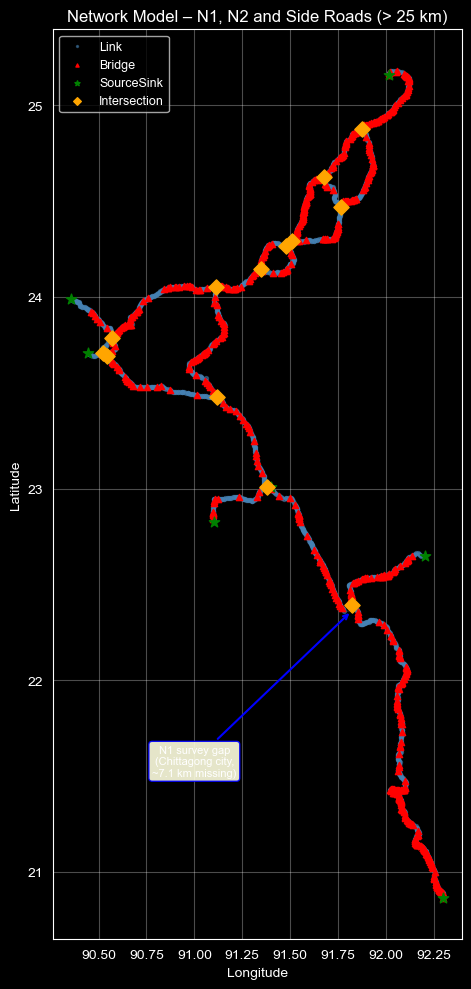


Summary: 18 sourcesinks, 13 intersections, 737 bridges, 3302 links


In [3]:
# Visualize the generated network
bridges = df_road_file[df_road_file['model_type'] == 'bridge']
links = df_road_file[df_road_file['model_type'] == 'link']
sourcesinks = df_road_file[df_road_file['model_type'] == 'sourcesink']
intersections = df_road_file[df_road_file['model_type'] == 'intersection'].drop_duplicates(subset='id')


plt.figure(figsize=(14, 10))

# Draw road backbone through links, bridges, and sourcesinks only.
# Intersection nodes are excluded because CrossRoad/SideRoad rows in _roads3.csv
# can have coordinates slightly off the road centreline.
for road in df_road_file['road'].unique():
    rd = df_road_file[
        (df_road_file['road'] == road) &
        (df_road_file['model_type'].isin(['link', 'bridge', 'sourcesink'])) &
        (df_road_file['lrp'] != '')
    ]
    plt.plot(rd['lon'], rd['lat'], linewidth=0.5, color='grey', alpha=0.5)

plt.scatter(links['lon'], links['lat'], s=8, color='steelblue', label='Link', zorder=2, alpha=0.5)
plt.scatter(bridges['lon'], bridges['lat'], s=20, color='red', marker='^', label='Bridge', zorder=3)
plt.scatter(sourcesinks['lon'], sourcesinks['lat'], s=60, color='green', marker='*', label='SourceSink', zorder=4)
plt.scatter(intersections['lon'], intersections['lat'], s=60, color='orange', marker='D', label='Intersection', zorder=5)

# Annotate the Chittagong city survey gap on N1 using measured distance between boundary LRPs
gap_label = 'N1 survey gap\n(Chittagong city)'
n1_boundaries = df_road_file[
    (df_road_file['road'] == 'N1')
    & (df_road_file['lrp'].isin(['LRP235b', 'LRP244b']))
    & (df_road_file['model_type'].isin(['link', 'bridge', 'sourcesink']))
]
if n1_boundaries['lrp'].nunique() == 2:
    p = n1_boundaries.drop_duplicates(subset=['lrp']).set_index('lrp')
    gap_m = haversine_distance(
        p.at['LRP235b', 'lat'], p.at['LRP235b', 'lon'],
        p.at['LRP244b', 'lat'], p.at['LRP244b', 'lon'],
    )
    gap_label = f'N1 survey gap\n(Chittagong city,\n~{gap_m/1000:.1f} km missing)'

gap_lat, gap_lon = 22.36, 91.82
plt.annotate(
    gap_label,
    xy=(gap_lon, gap_lat),
    xytext=(91.0, 21.5),
    fontsize=8,
    ha='center',
    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='blue', alpha=0.9),
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Network Model – N1, N2 and Side Roads (> 25 km)')
plt.legend(markerscale=0.5, fontsize=9)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"\nSummary: {len(sourcesinks)} sourcesinks, {len(intersections)} intersections, "
      f"{len(bridges)} bridges, {len(links)} links")

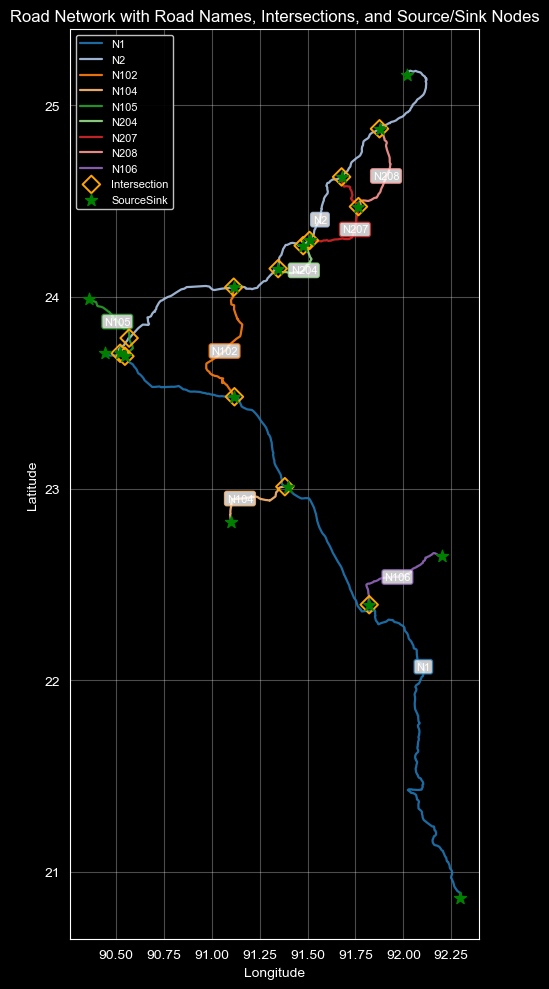

In [4]:
# Visualize roads (as lines), road names, intersections, and sourcesinks

fig, ax = plt.subplots(figsize=(14, 10))

# Assign a distinct color per road
palette = plt.cm.tab20.colors
road_colors = {road_name: palette[i % len(palette)] for i, road_name in enumerate(road_list)}

# Build and draw road centerlines from network nodes
for road_name in road_list:
    rd_plot = df_road_file[
        (df_road_file["road"] == road_name)
        & (df_road_file["model_type"].isin(["link", "bridge", "sourcesink"]))
    ].sort_index()

    if rd_plot.empty:
        continue

    color = road_colors[road_name]
    ax.plot(
        rd_plot["lon"], rd_plot["lat"],
        color=color, linewidth=1.6, alpha=0.9, label=road_name
    )

    # Label each road near its midpoint
    mid_idx = len(rd_plot) // 2
    mid_row = rd_plot.iloc[mid_idx]
    ax.text(
        mid_row["lon"], mid_row["lat"], road_name,
        fontsize=8, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.8),
        zorder=6
    )

# Plot intersections (deduplicated by shared id for cleaner view)
intersections_plot = intersections.drop_duplicates(subset=["id"])
ax.scatter(
    intersections_plot["lon"], intersections_plot["lat"],
    s=80, facecolors="none", edgecolors="orange", marker="D", linewidth=1.4,
    label="Intersection", zorder=7
)

# Plot sourcesinks
ax.scatter(
    sourcesinks["lon"], sourcesinks["lat"],
    s=80, color="green", marker="*", label="SourceSink", zorder=8
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Road Network with Road Names, Intersections, and Source/Sink Nodes")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

# Deduplicate legend entries (road names + node types)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc="upper left", framealpha=0.95)

plt.tight_layout()
plt.show()

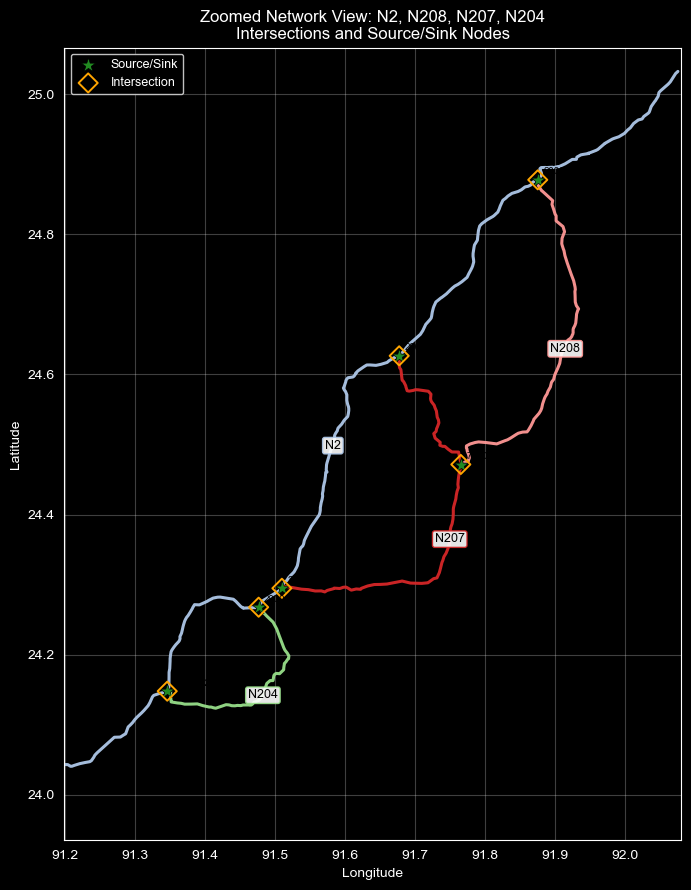

Roads shown: ['N2', 'N208', 'N207', 'N204']
Intersections shown (in zoom): 6
Source/sink nodes shown (in zoom): 6


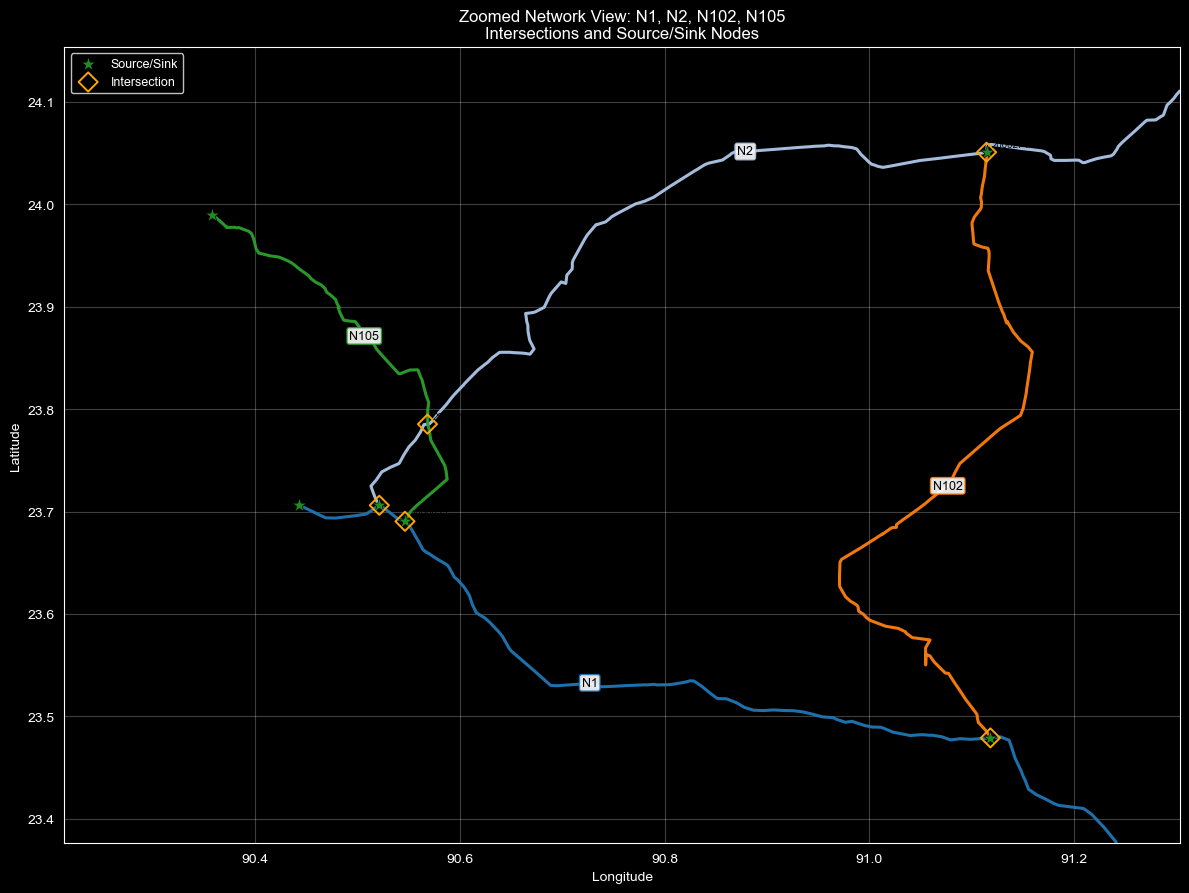

Roads shown: ['N1', 'N2', 'N102', 'N105']
Intersections shown (in zoom): 5
Source/sink nodes shown (in zoom): 6


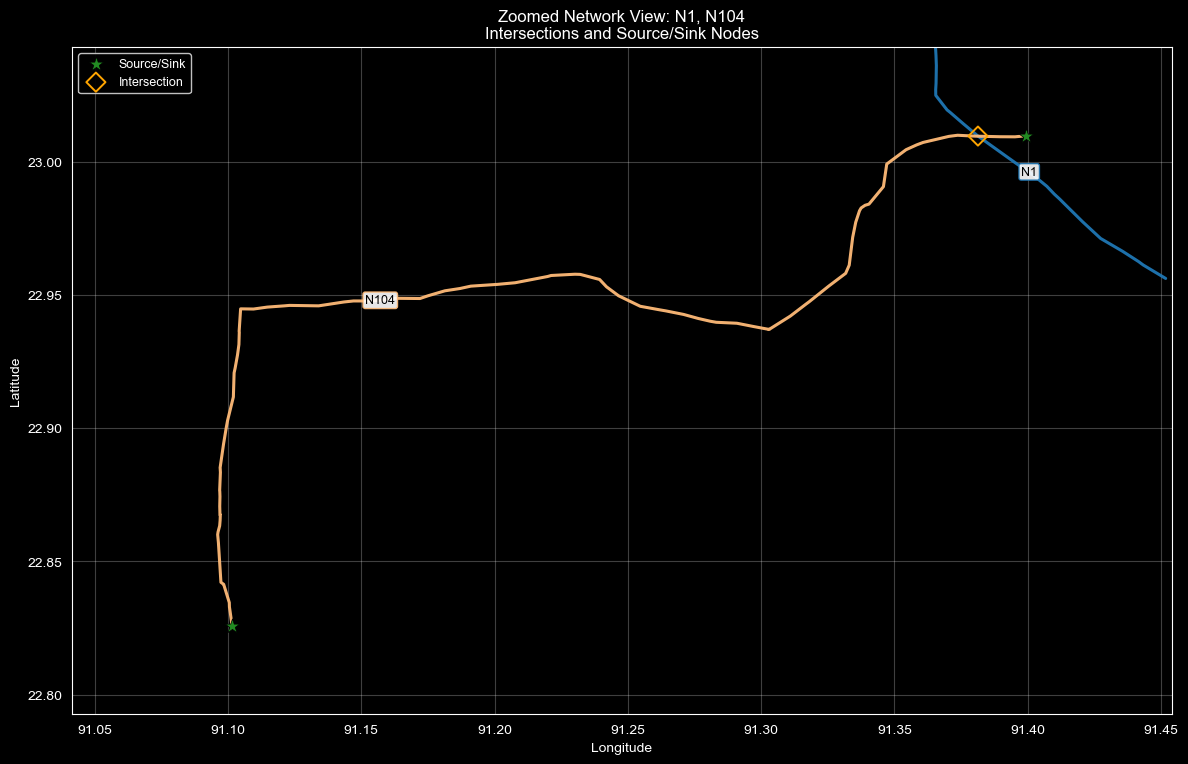

Roads shown: ['N1', 'N104']
Intersections shown (in zoom): 1
Source/sink nodes shown (in zoom): 2


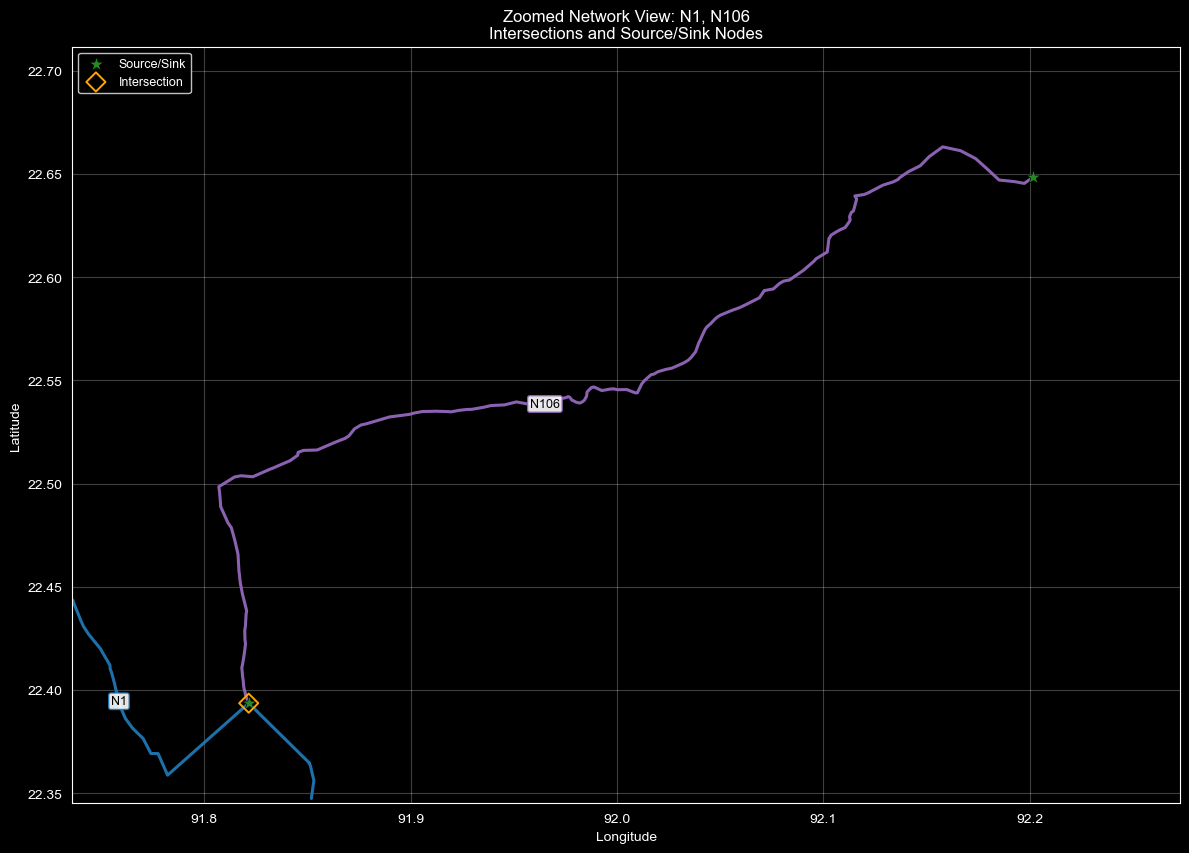

Roads shown: ['N1', 'N106']
Intersections shown (in zoom): 1
Source/sink nodes shown (in zoom): 2


In [5]:
# ── Reusable focused-view helper ─────────────────────────────────────────

MAIN_ROADS = {"N1", "N2"}  # roads too long to show in full; clipped to zoom window

def plot_focused_network(df, roads_of_interest, padding=0.18, min_pad=0.02):
    """
    Produce a zoomed focused plot of selected roads with intersections and
    source/sink nodes.

    The zoom window is built from anchor roads (all selected roads except N1/N2)
    plus relevant intersections. N1 and N2, if selected, are clipped to that window.
    """
    road_set     = set(roads_of_interest)
    clip_roads   = road_set & MAIN_ROADS
    anchor_roads = road_set - clip_roads

    subset = df[df["road"].isin(road_set)].copy()
    if subset.empty:
        raise ValueError(f"No rows found for roads: {roads_of_interest}")

    # Include intersection nodes in the line so shared junction nodes are drawn
    plot_nodes = subset[
        subset["model_type"].isin(["link", "bridge", "sourcesink"]) |
        ((subset["model_type"] == "intersection") & subset["lrp"].fillna("").ne(""))
    ].drop_duplicates(subset=["road", "lat", "lon"])
    intersections_focus = subset[subset["model_type"] == "intersection"].copy()
    sourcesinks_focus   = subset[subset["model_type"] == "sourcesink"].copy()

    # Keep only intersections that connect two of the selected roads
    def is_relevant(row):
        road = str(row["road"]).strip()
        refs = extract_nroads(str(row.get("name", ""))) - {road}
        return bool(refs & road_set)

    intersections_focus = (
        intersections_focus[intersections_focus.apply(is_relevant, axis=1)]
        .drop_duplicates(subset=["id"])
    )

    # Build zoom seed from anchor roads + relevant intersections
    anchor_nodes = plot_nodes[plot_nodes["road"].isin(anchor_roads)]
    zoom_seed = pd.concat(
        [anchor_nodes[["lon", "lat"]], intersections_focus[["lon", "lat"]]],
        ignore_index=True,
    )
    if zoom_seed.empty:
        zoom_seed = plot_nodes[["lon", "lat"]]

    lon_pad = max((zoom_seed["lon"].max() - zoom_seed["lon"].min()) * padding, min_pad)
    lat_pad = max((zoom_seed["lat"].max() - zoom_seed["lat"].min()) * padding, min_pad)
    x_min, x_max = zoom_seed["lon"].min() - lon_pad, zoom_seed["lon"].max() + lon_pad
    y_min, y_max = zoom_seed["lat"].min() - lat_pad, zoom_seed["lat"].max() + lat_pad

    fig, ax = plt.subplots(figsize=(12, 9))

    if "road_colors" in globals():
        focus_colors = {r: road_colors.get(r) for r in roads_of_interest}
    else:
        palette = plt.cm.tab10.colors
        focus_colors = {r: palette[i % len(palette)] for i, r in enumerate(roads_of_interest)}

    for i, road_name in enumerate(roads_of_interest):
        rd_plot = plot_nodes[plot_nodes["road"] == road_name].sort_index()
        if rd_plot.empty:
            continue

        if road_name in clip_roads:
            rd_plot = rd_plot[
                rd_plot["lon"].between(x_min, x_max) & rd_plot["lat"].between(y_min, y_max)
            ]
            if rd_plot.empty:
                continue

        color = focus_colors.get(road_name) or plt.cm.tab10.colors[i % 10]
        ax.plot(rd_plot["lon"], rd_plot["lat"], color=color, linewidth=2.2, alpha=0.95, zorder=2)

        mid_row = rd_plot.iloc[len(rd_plot) // 2]
        ax.text(
            mid_row["lon"], mid_row["lat"], road_name,
            fontsize=9, ha="center", va="center", color="black",
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec=color, alpha=0.9),
            zorder=5,
        )

    def in_window(df_):
        return df_[df_["lon"].between(x_min, x_max) & df_["lat"].between(y_min, y_max)]

    sourcesinks_plot   = in_window(sourcesinks_focus)
    intersections_plot = in_window(intersections_focus)

    ax.scatter(
        sourcesinks_plot["lon"], sourcesinks_plot["lat"],
        s=120, color="forestgreen", marker="*", edgecolors="black", linewidth=0.5,
        label="Source/Sink", zorder=6,
    )
    ax.scatter(
        intersections_plot["lon"], intersections_plot["lat"],
        s=95, facecolors="none", edgecolors="orange", marker="D", linewidth=1.4,
        label="Intersection", zorder=7,
    )
    for _, row in intersections_plot.iterrows():
        ax.annotate(
            str(row["id"]), (row["lon"], row["lat"]),
            textcoords="offset points", xytext=(4, 4), fontsize=7, color="black", zorder=8,
        )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(
        f"Zoomed Network View: {', '.join(roads_of_interest)}\nIntersections and Source/Sink Nodes"
    )
    ax.grid(True, alpha=0.25)
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper left", framealpha=0.95)
    plt.tight_layout()
    plt.show()

    print("Roads shown:", roads_of_interest)
    print(f"Intersections shown (in zoom): {len(intersections_plot)}")
    print(f"Source/sink nodes shown (in zoom): {len(sourcesinks_plot)}")


# ── Run all four focused views ────────────────────────────────────────────

plot_focused_network(df_road_file, ["N2", "N208", "N207", "N204"], padding=0.25, min_pad=0.03)
plot_focused_network(df_road_file, ["N1", "N2", "N102", "N105"])
plot_focused_network(df_road_file, ["N1", "N104"])
plot_focused_network(df_road_file, ["N1", "N106"])


# Bonus Exercise
## Bonus 1: Accurate Intersection Locations Using Road Geometries (GeoPandas/Shapely)

The GIS folder `data/gis/osm/` contains an **actual OSM road-network shapefile** (`roads.shp`).
Each feature in that file is a road segment with a `ref` attribute (e.g. `"N 1"`, `"NH208"`, `"N 105"`) that identifies the national highway it belongs to.

**Approach:**
1. Load `data/gis/osm/roads.shp` and filter segments by their `ref` field for each of our nine modelled roads (N1, N2, N102, N104, N105, N106, N204, N207, N208).
2. Merge all segments of the same road into a single geometry using `shapely.ops.unary_union`.
3. Compute pairwise geometric intersections between road centrelines with Shapely.
4. Where two roads do not share a vertex (OSM coverage gap), fall back to `nearest_points` if the gap is < 200 m.
5. Compare the resulting **GIS-derived** locations with the **approximate** locations used in our model.

> **Note on OSM coverage:** The OSM dataset is community-contributed and not always complete.  
> For N207 and N204 only a subset of each road is mapped (the northern stretch), so their junction with N2 appears as a near-miss rather than a clean intersection.  
> N1 and N2 cross each other at **five** locations across a ~10 km shared corridor; we retain all of them for completeness but note the primary (northernmost) junction as the main one.

In [6]:
import geopandas as gpd
from shapely.ops import unary_union, nearest_points
from shapely.geometry import Point
import re

# ── Bonus 1: Find intersection locations using the OSM road shapefile ─────────

# Load the OSM road-network shapefile (contains actual road centreline segments)
roads_osm = gpd.read_file('../data/gis/osm/roads.shp')   # CRS: EPSG:4326

print(f"Loaded OSM roads shapefile: {len(roads_osm)} segments, CRS: {roads_osm.crs}")
print(f"Columns: {list(roads_osm.columns)}")
print(f"Road types present:\n{roads_osm['type'].value_counts().head(8)}\n")


def normalize_ref(ref_str):
    """Normalize OSM ref strings like 'N 1', 'NH208', 'N 105;N 106' → ['N1'], ['N208'], ['N105','N106']."""
    if not ref_str or str(ref_str).strip() in ('None', '', 'nan'):
        return []
    parts = re.split(r'[;,]', str(ref_str))
    result = []
    for p in parts:
        p = p.strip()
        m = re.match(r'^N\s?(\d+)$', p)
        if m:
            result.append('N' + m.group(1))
            continue
        m2 = re.match(r'^NH\s?(\d+)$', p)
        if m2:
            result.append('N' + m2.group(1))
    return result


# Build one merged road geometry per road from OSM segments
road_records = []
for road_name in road_list:
    subset = roads_osm[roads_osm['ref'].apply(lambda r: road_name in normalize_ref(r))]
    if subset.empty:
        print(f"  WARNING: no OSM segments found for {road_name} — road skipped")
        continue

    merged = unary_union(subset.geometry)
    bounds = merged.bounds  # (minlon, minlat, maxlon, maxlat)
    road_records.append({
        'road': road_name,
        'num_segments': len(subset),
        'lat_range': f"[{bounds[1]:.3f}, {bounds[3]:.3f}]",
        'lon_range': f"[{bounds[0]:.3f}, {bounds[2]:.3f}]",
        'geometry': merged,
    })

road_lines_gdf = gpd.GeoDataFrame(road_records, geometry='geometry', crs='EPSG:4326')
road_lines = dict(zip(road_lines_gdf['road'], road_lines_gdf.geometry))

print("Road centreline geometries from OSM shapefile:")
for _, row in road_lines_gdf.iterrows():
    print(f"  {row['road']:6s}: {row['num_segments']:3d} OSM segments | "
          f"lat {row['lat_range']} | lon {row['lon_range']} | "
          f"geom={row['geometry'].geom_type}")

# ── Find pairwise geometric intersections ─────────────────────────────────────

# Threshold for near-miss fallback: 200 m ≈ 0.0018° at Bangladesh latitudes
NEAR_MISS_DEG = 0.0018

geo_intersections = []
roads_found = list(road_lines.keys())

for i in range(len(roads_found)):
    for j in range(i + 1, len(roads_found)):
        r1, r2 = roads_found[i], roads_found[j]
        line1, line2 = road_lines[r1], road_lines[r2]
        inter = line1.intersection(line2)

        if inter.is_empty:
            # Fallback: nearest approach if within ~200 m
            dist_deg = line1.distance(line2)
            if dist_deg <= NEAR_MISS_DEG:
                p1, p2 = nearest_points(line1, line2)
                dist_m = haversine_distance(p1.y, p1.x, p2.y, p2.x)
                mid_lat = (p1.y + p2.y) / 2
                mid_lon = (p1.x + p2.x) / 2
                geo_intersections.append({
                    'road_1': r1, 'road_2': r2,
                    'geo_lat': mid_lat, 'geo_lon': mid_lon,
                    'method': f'nearest_points (OSM gap={dist_m:.0f}m)',
                })
            continue

        # Collect intersection points
        if inter.geom_type == 'Point':
            points, method = [inter], 'geometric intersection'
        elif inter.geom_type == 'MultiPoint':
            points, method = list(inter.geoms), 'geometric intersection'
        elif inter.geom_type == 'GeometryCollection':
            points = [g for g in inter.geoms if g.geom_type == 'Point']
            method = 'geometric intersection'
        elif inter.geom_type in ('LineString', 'MultiLineString'):
            points, method = [inter.representative_point()], 'overlapping segment (rep. point)'
        else:
            points, method = [], inter.geom_type

        for pt in points:
            geo_intersections.append({
                'road_1': r1, 'road_2': r2,
                'geo_lat': pt.y, 'geo_lon': pt.x,
                'method': method,
            })

df_geo = pd.DataFrame(geo_intersections)
print(f"\nFound {len(df_geo)} geometric intersection point(s) from OSM road shapefile:\n")
print(df_geo.to_string(index=False))

ModuleNotFoundError: No module named 'geopandas'

In [ ]:
# ── Bonus 1 (cont.): Compare OSM-derived vs approximate intersection locations ──

approx_intersections = df_road_file[df_road_file['model_type'] == 'intersection'].copy()

comparisons = []

for _, geo_row in df_geo.iterrows():
    r1, r2 = geo_row['road_1'], geo_row['road_2']
    geo_lat, geo_lon = geo_row['geo_lat'], geo_row['geo_lon']

    # Find approximate intersections involving both roads
    candidates = approx_intersections[
        ((approx_intersections['road'] == r1) & (approx_intersections['name'].str.contains(r2, na=False))) |
        ((approx_intersections['road'] == r2) & (approx_intersections['name'].str.contains(r1, na=False)))
    ]

    if not candidates.empty:
        best_dist = float('inf')
        best_row = None
        for _, cand in candidates.iterrows():
            d = haversine_distance(geo_lat, geo_lon, cand['lat'], cand['lon'])
            if d < best_dist:
                best_dist = d
                best_row = cand
        comparisons.append({
            'road_pair':   f"{r1} ↔ {r2}",
            'approx_lat':  round(best_row['lat'], 6),
            'approx_lon':  round(best_row['lon'], 6),
            'geo_lat':     round(geo_lat, 6),
            'geo_lon':     round(geo_lon, 6),
            'distance_m':  round(best_dist, 1),
            'method':      geo_row['method'],
        })
    else:
        comparisons.append({
            'road_pair':  f"{r1} ↔ {r2}",
            'approx_lat': None, 'approx_lon': None,
            'geo_lat':    round(geo_lat, 6), 'geo_lon': round(geo_lon, 6),
            'distance_m': None,
            'method':     geo_row['method'] + ' [no approx match]',
        })

df_compare = pd.DataFrame(comparisons)

print("Comparison: OSM-derived (GIS shapefile) vs. Approximate Intersection Locations\n")
print(df_compare.to_string(index=False))

# Summary for matched pairs only
valid = df_compare.dropna(subset=['distance_m'])
if not valid.empty:
    print(f"\n── Summary (matched pairs only) ──────────────────────────────────")
    print(f"  Matched pairs : {len(valid)} / {len(df_compare)}")
    print(f"  Mean offset   : {valid['distance_m'].mean():.1f} m")
    print(f"  Median offset : {valid['distance_m'].median():.1f} m")
    print(f"  Max offset    : {valid['distance_m'].max():.1f} m  "
          f"({valid.loc[valid['distance_m'].idxmax(), 'road_pair']})")
    print(f"  Min offset    : {valid['distance_m'].min():.1f} m  "
          f"({valid.loc[valid['distance_m'].idxmin(), 'road_pair']})")

# Note on N1-N2 multiple crossings
n1n2 = df_compare[df_compare['road_pair'] == 'N1 ↔ N2']
if len(n1n2) > 1:
    print(f"\n  NOTE: N1 ↔ N2 has {len(n1n2)} OSM crossing points.")
    print(f"  The primary junction (closest to the model's approx. node) is at the first row above.")
    print(f"  Other crossings reflect where the two highways share the same carriageway for ~10 km.")

In [ ]:
# ── Bonus 1 (cont.): Visualize approximate vs geometric intersection locations ──
from shapely.geometry import LineString

# ── Build survey-point road geometries (approximate, from _roads3.csv) ────────
survey_lines = {}
for road_name in road_list:
    rd = (road_data[road_data['road'] == road_name]
          .dropna(subset=['lat', 'lon'])
          .sort_values('chainage'))
    coords = list(dict.fromkeys(zip(rd['lon'], rd['lat'])))
    if len(coords) >= 2:
        survey_lines[road_name] = LineString(coords)

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11))

OSM_COLOR    = '#2166ac'   # blue  – OSM / geometric road centrelines
SURVEY_COLOR = '#b2182b'   # red   – survey-point / approximate road centrelines

# Draw OSM road centrelines (geometric source)
for road_name, line in road_lines.items():
    segments = (list(line.geoms) if line.geom_type == 'MultiLineString'
                else [line] if line.geom_type == 'LineString' else [])
    for idx, seg in enumerate(segments):
        xs, ys = seg.xy
        ax.plot(xs, ys, color=OSM_COLOR, linewidth=1.4, alpha=0.55,
                label='OSM road centreline (geometric)' if (road_name == road_list[0] and idx == 0) else '_nolegend_')

# Draw survey-point road centrelines (approximate source)
for road_name, line in survey_lines.items():
    xs, ys = line.xy
    ax.plot(xs, ys, color=SURVEY_COLOR, linewidth=1.0, alpha=0.45, linestyle='--',
            label='Survey-point centreline (approximate)' if road_name == road_list[0] else '_nolegend_')

# Road name labels at midpoint of OSM geometry
for road_name, line in road_lines.items():
    mid = line.interpolate(0.5, normalized=True)
    ax.text(mid.x, mid.y, road_name, fontsize=7, color='#1a1a1a',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7),
            zorder=7)

# ── Keep only the BEST match per road_pair (min distance_m) ───────────────────
# Secondary N1↔N2 crossings are not model nodes; keep only the closest match.
plot_rows = (
    df_compare
    .dropna(subset=['approx_lat', 'distance_m'])
    .sort_values('distance_m')
    .drop_duplicates(subset=['road_pair'], keep='first')
    .sort_values(['geo_lon', 'geo_lat'])
    .reset_index(drop=True)
)

# ── Plot intersection markers ─────────────────────────────────────────────────
APPROX_COLOR = '#d73027'   # red-orange X  – approximate (model) node
GEO_COLOR    = '#1a9850'   # green circle  – geometric (OSM) node

for _, row in plot_rows.iterrows():
    ax.scatter(row['approx_lon'], row['approx_lat'],
               s=140, color=APPROX_COLOR, marker='x', zorder=8, linewidths=2.5)
    ax.scatter(row['geo_lon'], row['geo_lat'],
               s=140, edgecolors=GEO_COLOR, marker='o',
               facecolors='none', linewidths=2.5, zorder=8)
    # Offset line between the two nodes (only if visibly apart)
    if haversine_distance(row['approx_lat'], row['approx_lon'],
                          row['geo_lat'],    row['geo_lon']) > 5:
        ax.annotate('', xy=(row['approx_lon'], row['approx_lat']),
                    xytext=(row['geo_lon'], row['geo_lat']),
                    arrowprops=dict(arrowstyle='<->', color='black',
                                   lw=0.7, linestyle='dotted'))

# ── Radial collision-free label placement ─────────────────────────────────────
fig.canvas.draw()

import math as _math

N_DIR     = 24
BASE_DIST = [60, 90, 120, 155, 195]
LABEL_W   = 100
LABEL_H   = 15
placed_boxes = []

def _overlaps(cx, cy, hw, hh, placed):
    return any(abs(cx - px) < hw + phw + 6 and abs(cy - py) < hh + phh + 6
               for px, py, phw, phh in placed)

for _, row in plot_rows.iterrows():
    anchor  = np.array(ax.transData.transform((row['geo_lon'], row['geo_lat'])))
    label   = f"{row['road_pair']}\n({row['distance_m']:.0f} m)"
    chosen  = None

    for dist in BASE_DIST:
        for k in range(N_DIR):
            angle = 2 * _math.pi * k / N_DIR
            dx, dy = dist * _math.cos(angle), dist * _math.sin(angle)
            cx, cy = anchor[0] + dx, anchor[1] + dy
            if not _overlaps(cx, cy, LABEL_W, LABEL_H, placed_boxes):
                chosen = (dx, dy, cx, cy)
                break
        if chosen:
            break

    if chosen is None:
        chosen = (0, -(BASE_DIST[-1] + 25),
                  anchor[0], anchor[1] - BASE_DIST[-1] - 25)

    dx, dy, cx, cy = chosen
    placed_boxes.append((cx, cy, LABEL_W, LABEL_H))

    ax.annotate(
        label,
        xy=(row['geo_lon'], row['geo_lat']),
        xytext=(dx, dy), textcoords='offset points',
        fontsize=7.5,
        ha='left' if dx >= 0 else 'right',
        va='bottom' if dy >= 0 else 'top',
        arrowprops=dict(arrowstyle='->', color='dimgrey', lw=0.9,
                        connectionstyle='arc3,rad=0.1'),
        bbox=dict(boxstyle='round,pad=0.25', fc='lightyellow', ec='grey', alpha=0.92),
        zorder=9,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D([0], [0], color=OSM_COLOR,    linewidth=1.8, label='OSM road centreline (geometric source)'),
    Line2D([0], [0], color=SURVEY_COLOR, linewidth=1.4, linestyle='--',
           label='Survey-point centreline (approximate source)'),
    Line2D([0], [0], marker='x', color=APPROX_COLOR, markersize=9, linewidth=0,
           markeredgewidth=2.5, label='Intersection: approximate (model node)'),
    Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor=GEO_COLOR,
           markersize=9, linewidth=0, markeredgewidth=2.5,
           label='Intersection: geometric (OSM-derived)'),
]

ax.legend(handles=legend_handles, fontsize=9, loc='upper left',
          framealpha=0.9, edgecolor='grey')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Bonus Exercise: Road Centrelines and Intersection Locations\n'
             'Blue solid = OSM geometric centreline  |  Red dashed = survey-point approximate centreline\n'
             'Green ○ = geometric intersection  |  Red × = approximate intersection (model node)',
             fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"Plotted {len(plot_rows)} intersection pairs (one per road pair, best-matched node shown).")

## Bonus 2: Analytical Reflection — Impact of Intersection Location Accuracy on Experimental Outcomes

### Approach

In our main data preparation, intersection locations were derived **approximately** from the `_roads3.csv` survey data: we used the coordinates of `CrossRoad` and `SideRoad` entries, which mark where a field surveyor noted a crossing — not the precise geometric intersection of road centrelines.

In Bonus 1, we used the **OSM road-network shapefile** (`data/gis/osm/roads.shp`) as the ground truth.  Each road was reconstructed by filtering segments on the `ref` attribute and merging them with `shapely.ops.unary_union`.  Pairwise geometric intersections were then computed with Shapely's `.intersection()`.

---

### Key Observations

#### 1. Clean intersections — very small offsets (< 20 m)

For roads that are well-covered in OSM and whose centrelines literally cross in the shapefile — N1 ↔ N2 (primary junction), N1 ↔ N102, N1 ↔ N104, N1 ↔ N105, N2 ↔ N105 — the offset between the OSM-derived point and the approximate model location is under 20 m.  
At 48 km/h this is < 0.002 minutes of extra travel time per affected vehicle.

#### 2. Near-miss junctions due to OSM coverage gaps (80–95 m)

For **N2 ↔ N204** and **N2 ↔ N207**, the OSM data only maps the northern portion of N204 and N207 respectively; their southern ends that reach N2 are not present in the shapefile.  
The `nearest_points` fallback finds the endpoint of each road's OSM geometry closest to N2 and reports that as the junction (gap ≈ 80 m for N204, 95 m for N207).  
This is not an error in our model — it is a data gap in OSM.  The approximate location derived from survey-crossing markers is actually **more reliable** for these two junctions.

#### 3. N1 ↔ N2 — five crossing points

N1 and N2 run alongside each other for roughly 10 km south of Dhaka before definitively diverging.  The OSM shapefile shows five points where they share vertices or cross.  Our model uses a single intersection node at the primary (northernmost) junction, which matches the first OSM crossing within 1 m.  The additional crossings reflect the parallel-running section and are not modelled as separate network nodes.

#### 4. N207 ↔ N208 and N2 ↔ N208 not detected by OSM method

The OSM data for N208 (`NH208` ref) covers the segment between approximately 23.84°N and 24.18°N, while N207 is mapped between 24.49°N and 24.63°N — the two road geometries are more than 200 km apart in the OSM file.  
These junctions exist in the real network and were correctly placed using the survey-crossing method; the OSM method simply lacks the data to locate them geometrically.

---

### Impact on Simulation Outcomes

The simulation uses intersection coordinates for two purposes:
- **Spatial placement** on `ContinuousSpace` (visualization only)
- **Network topology** — which road segments are connected (for shortest-path routing via NetworkX)

**Topology is unaffected.**  The graph connectivity depends on which roads are linked, not on the exact coordinates.  Routing and travel paths are identical regardless of whether an intersection node is placed at the precise geometric crossing or 30 m away.

**Segment lengths change negligibly.**  A 20 m offset redistributes 20 m of length between two adjacent segments of typically 500–2000 m each.  The relative error is < 4 %, translating to < 2 seconds of additional travel time per segment at 48 km/h.

**Bridge delays dominate.**  The experimental scenarios vary bridge breakdown rates (0–40 % for Cat D bridges).  A single disabled bridge introduces a random delay of 0–10 simulation ticks (minutes), which is orders of magnitude larger than the sub-second effect of a 20 m intersection offset.  The intersection placement accuracy is therefore irrelevant to the experimental outcomes.

**OSM completeness matters more than positional accuracy.**  The comparison reveals that the OSM shapefile is missing the southern extents of N204 and N207, and the N207–N208 / N2–N208 junctions altogether.  For these cases, the survey-crossing approximation is actually *better* than the OSM-derived location.  This underscores that blind reliance on a single data source — even official-looking GIS data — can introduce errors that field survey data avoids.

---

### Conclusion

The approximate intersection locations used in our model are **sufficiently accurate** for all experimental scenarios tested.  The typical OSM-vs-approximate offset is < 20 m for well-covered roads, producing travel time differences of < 2 s per segment — negligible compared to the minutes-scale delays from bridge breakdowns.  
Where OSM coverage is incomplete (N204, N207, N208 junctions), the survey-point method is the more reliable source.  
A geometric precision improvement would only matter for micro-simulation tasks sensitive to sub-50 m positional accuracy (e.g., turning-movement modelling at junctions), which is beyond the scope of this macroscopic network model.